# EarthCARE Data Analysis with MAAP - ectools Tutorial

**Authors:** Andreas Karipis, Dimitra Karkani
**Institution:** National Observatory of Athens (NOA)  

This tutorial shows how to query the ESA MAAP catalog and load EarthCARE data for analysis. 

**What you need:**
- An authorized EOIAM account
- A valid Bearer token (get this from your EOIAM account)

**What you'll learn:**
- Search for EarthCARE products in MAAP
- Load ATLID data directly from the cloud
- Calculate stratospheric aerosol optical depth (AOD)
- Save processed data for analysis

### Setup and Import


In [ ]:
pip install pystac_client netcdf4 h5py requests aiohttp h5netcdf


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd 
import requests
from IPython.display import Image, display
import os 
import pathlib
from ectools import ecio  # Make sure this library is installed
# import netCDF4  
# import aiohttp
# import requests
# import h5netcdf

### Authentication - Token
You can generate the token [here](https://portal.maap.eo.esa.int/ini/services/auth/token/index.php). Currently this is valid for 90 days! 

You need to create a txt file with tyour eoiam credentials and then a function to load the token together with your credentials. For more information see documentation: [here](https://portal.maap.eo.esa.int/ini/kb/books/collaborative-environment-pal/page/earthcare-maap)



In [ ]:
exec(open('token_auth.py').read())
from token_auth import get_token
token = get_token()

### ESA MAAP (STAC) Catalog API 
Point to the catalogue endpoint

In [ ]:
catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)

There are many EarthCARE collections which in turn contain the EarthCARE products. 
Currently the following collections have begun to be populated in the ESA MAAP catalogue: 

* EarthCAREL1Validated_MAAP
* EarthCAREL2Validated_MAAP 
* EarthCAREL1InstChecked_MAAP
* EarthCAREL2InstChecked_MAAP 
* EarthCAREL01L1Products_MAAP

In [ ]:
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

**Filter** - allows you to search based on different metadata parameters. To understand which queryables exist you can visit: [Queryables](https://catalog.maap.eo.esa.int/catalogue/collections/EarthCAREL1Validated_MAAP/queryables). 
Examples include: 
* productType
* frame 
* processingLevel
* instrument
* orbitNumber 
... 

**Datetime** represents the temporal coverage of the data. None can be used for both start and end to indicated unbounded queries.  

**bbox** is defined by the bottom left corner (longmin latmin) and the top right corner coordinates (longmax latmax) 


## Searching for Products

You can find out more about all EarthCARE products here: [here](https://earthcarehandbook.earth.esa.int/)

Now we'll search for ATLID cloud and aerosol products. You can modify the search parameters below:

In [ ]:
search = catalog.search(
    collections=EC_COLLECTION, 
    filter= " (productType = 'ATL_EBD_2A') AND productVersion = 'ba' AND frame = 'E' AND orbitNumber = 01380 ",
    # Filter by product type
    #bbox = [-25, -180, 25, 180],
    datetime = ['2024-07-24T00:00:00Z', '2024-08-26T00:00:00Z'], 
    method = 'GET', # This is necessary 
    #max_items=5  # Adjust as needed, given the large aoutn of products it is recommended to set a limit
)

items = list(search.items())
print(f"{search.matched()} items found that matched the query.")

NameError: name 'catalog' is not defined

### Results

Understanding Assets in the ESA MAAP STAC Catalog: Each granule (one frame of EarthCARE data per product) includes multiple **assets**, which are different files that serve distinct purposes. These assets can include preview images, scientific data, metadata, and more.

**Types of assets in a granule**:

| **Asset Name**        | **Description**                                                                 | **File Type** | **Purpose / Use**                                 |
|------------------------|---------------------------------------------------------------------------------|---------------|---------------------------------------------------|
| thumbnail / quicklook | Preview images of the granule area                                              | .jpeg       | Quick visual inspection                           |
| enclosure_h5         | Main scientific data file (e.g. EarthCARE Level 1B product)                          | .h5         | Use this for streaming or downloading the file(s) of interest.       |
| enclosure_hdr         | Header file with additional metadata for the data file                          | .HDR        | Provides structural information for .h5 file    |
| product             | Complete zipped product bundle                                                   | .zip        | For full download (not recommended unless necessary)  |
| metadata_ogc_10_157r4, metadata_ogc_17_003r2, metadata_iso_19139 | Metadata files for cataloging and discovery | .xml, .json |              |


**Tips**: 

- **Want a quick look?** Use the quicklook or thumbnail to preview the data.
- **Need to analyze?** Work with the enclosure_1 (the .h5 file)   this is demonstrated in the next cells.
- **Don't need everything?** Avoid the .zip unless you really need to download all files.
- **Curious about metadata?** Open the XML/JSON metadata files for detailed info.



First check the assets. **TC products (A_TC,AC_TC)** don't have quicklooks in the assets.

In [ ]:
# Check what assets actually exist
data = search.item_collection_as_dict()
available_assets = set()
for feature in data['features']:
    available_assets.update(feature.get('assets', {}).keys())
print("Available assets:", available_assets)

Available assets: {'metadata_iso_19139', 'metadata_ogc_17_003r2', 'enclosure_h5', 'metadata_ogc_10_157r4', 'thumbnail', 'product', 'enclosure_hdr', 'quicklook'}


In [ ]:
# Using Pandas dataframes for ease of use. This is not mandatory, but just a nice way to get an overview of the products you found through the search. Please note that pandas dataframes run into issues if we try to pass to many products. Use max_items! :) 
data = search.item_collection_as_dict()

df = pd.json_normalize(data, record_path=['features'])[
    [
        "id",
        "properties.product:type",                
        "properties.updated",                     
        "assets.product.href",
        "assets.quicklook.href",
        "assets.enclosure_h5.href",
        "assets.enclosure_hdr.href",
    ]
]

# Renaming the assets for 
df.rename(columns={
    'properties.product:type': 'product_type',
    'properties.updated': 'last_modified',
    'assets.product.href': 'Zipped Product',
    'assets.quicklook.href': 'quicklook_url',
    'assets.enclosure_h5.href': 'h5_url',
    'assets.enclosure_hdr.href': 'HDR_url',
}, inplace=True)

df.sort_values(by='id', ascending=True, inplace=True)


## Selecting a Product

Let's select the first product for analysis:

In [ ]:
# Select first product
selected_row = df.iloc[0]
ds_url = selected_row['h5_url']
product_id = selected_row['id']

print(f"Selected product: {product_id}")
print(f"Data URL: {ds_url}")

Selected product: ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E
Data URL: https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/ATL_EBD_2A/BA/2024/08/25/ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E/ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E/ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E.h5


## Stream and plot data

The **ATL_EBD_2A**'s data is contained in one group: 
* ScienceData

Let's inspect 

In [ ]:
fs = fsspec.filesystem("https", headers={"Authorization": f"Bearer {token}"})
with fs.open(ds_url, "rb") as f:
    #ds = xr.open_dataset(f, engine='h5netcdf', group='ScienceData')
    ds = ecio.load_AEBD(f)
    aebd=ds.load()
    aebd.encoding = ds.encoding.copy()  # Copy encoding metadata
    aebd.attrs = ds.attrs.copy() 


Selecting frame from 99 to 4964


In [ ]:
fs = fsspec.filesystem("https", headers={"Authorization": f"Bearer {token}"})
with fs.open(ds_url, "rb") as f:
    #ds = xr.open_dataset(f, engine='h5netcdf', group='ScienceData')
    ds = ecio.load_AEBD(f)
    aebd=ds.load()
    aebd.encoding = ds.encoding.copy()  # Copy encoding metadata
    aebd.attrs = ds.attrs.copy() 


Selecting frame from 99 to 4964


## Data Processing

Let's process the data to calculate stratospheric aerosol optical depth (AOD). We'll filter the data to keep only stratospheric levels and relevant aerosol types.

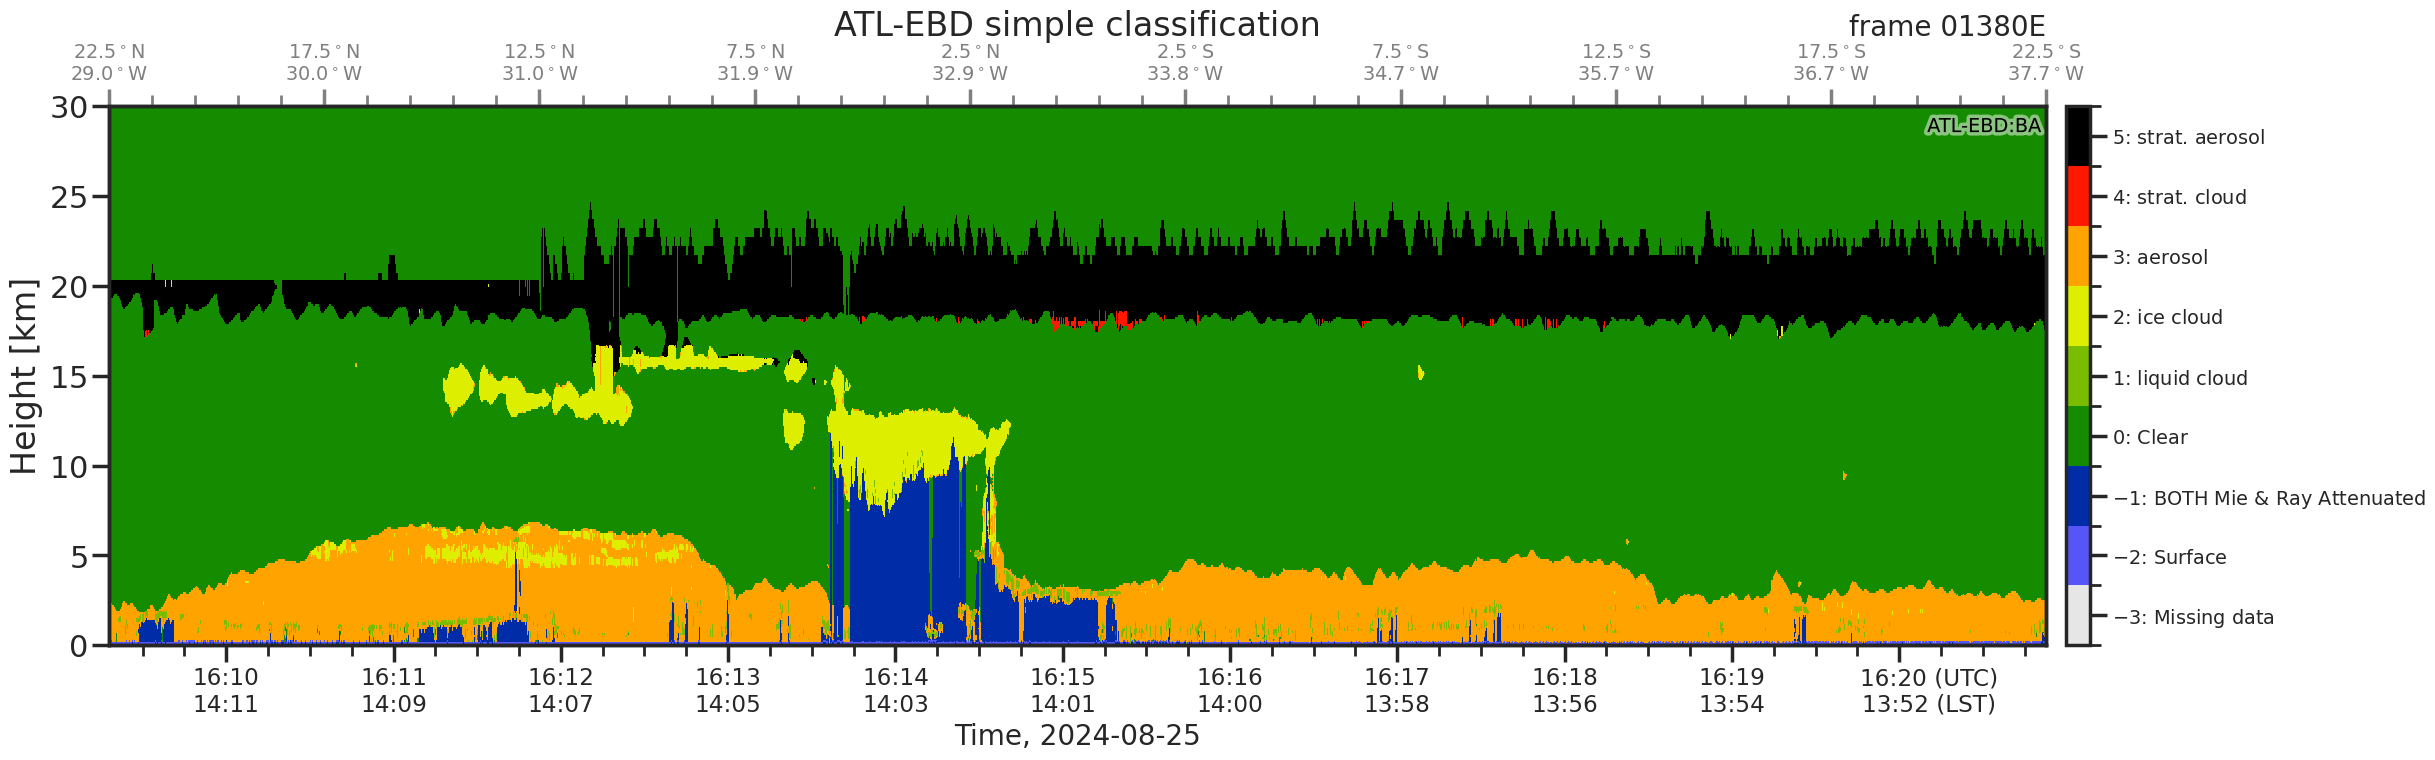

In [ ]:
from ectools import ecplot, colormaps
import numpy as np
fig, ax = plt.subplots(figsize=(25,7))
ecplot.plot_EC_target_classification(ax, aebd, "simple_classification", colormaps.chiljet2(np.linspace(0, 1, 9)), hmin=0, hmax=30e3)

**Analyse data - Stratospheric AOD calculation** \
You can directly do your analysis here and download the results. No need for local or hpc processing

First keep only the parameters we need for faster processing

In [ ]:
variables_to_keep = [
    'time', 'height', 'latitude', 'longitude', 'tropopause_height',
    'simple_classification', 'particle_extinction_coefficient_355nm_low_resolution',
    'lidar_ratio_355nm_low_resolution', 'particle_linear_depol_ratio_355nm_low_resolution'
]
aebd_f1 = aebd[variables_to_keep]

Second step - Keep only data above tropopause height

In [ ]:
original_time = aebd_f1['time']
original_longitude = aebd_f1['longitude'] 
original_latitude = aebd_f1['latitude']

# Apply the where filter
aebd_f2 = aebd_f1.where(aebd_f1['height'] >= aebd_f1['tropopause_height'])

# Restore the original 1D coordinates (don't let them get broadcasted with where())
aebd_f2['time'] = original_time
aebd_f2['longitude'] = original_longitude 
aebd_f2['latitude'] = original_latitude    
aebd_f2.encoding = aebd.encoding.copy()  # Copy encoding metadata
aebd_f2.attrs = aebd.attrs.copy()

Plot again to see the results

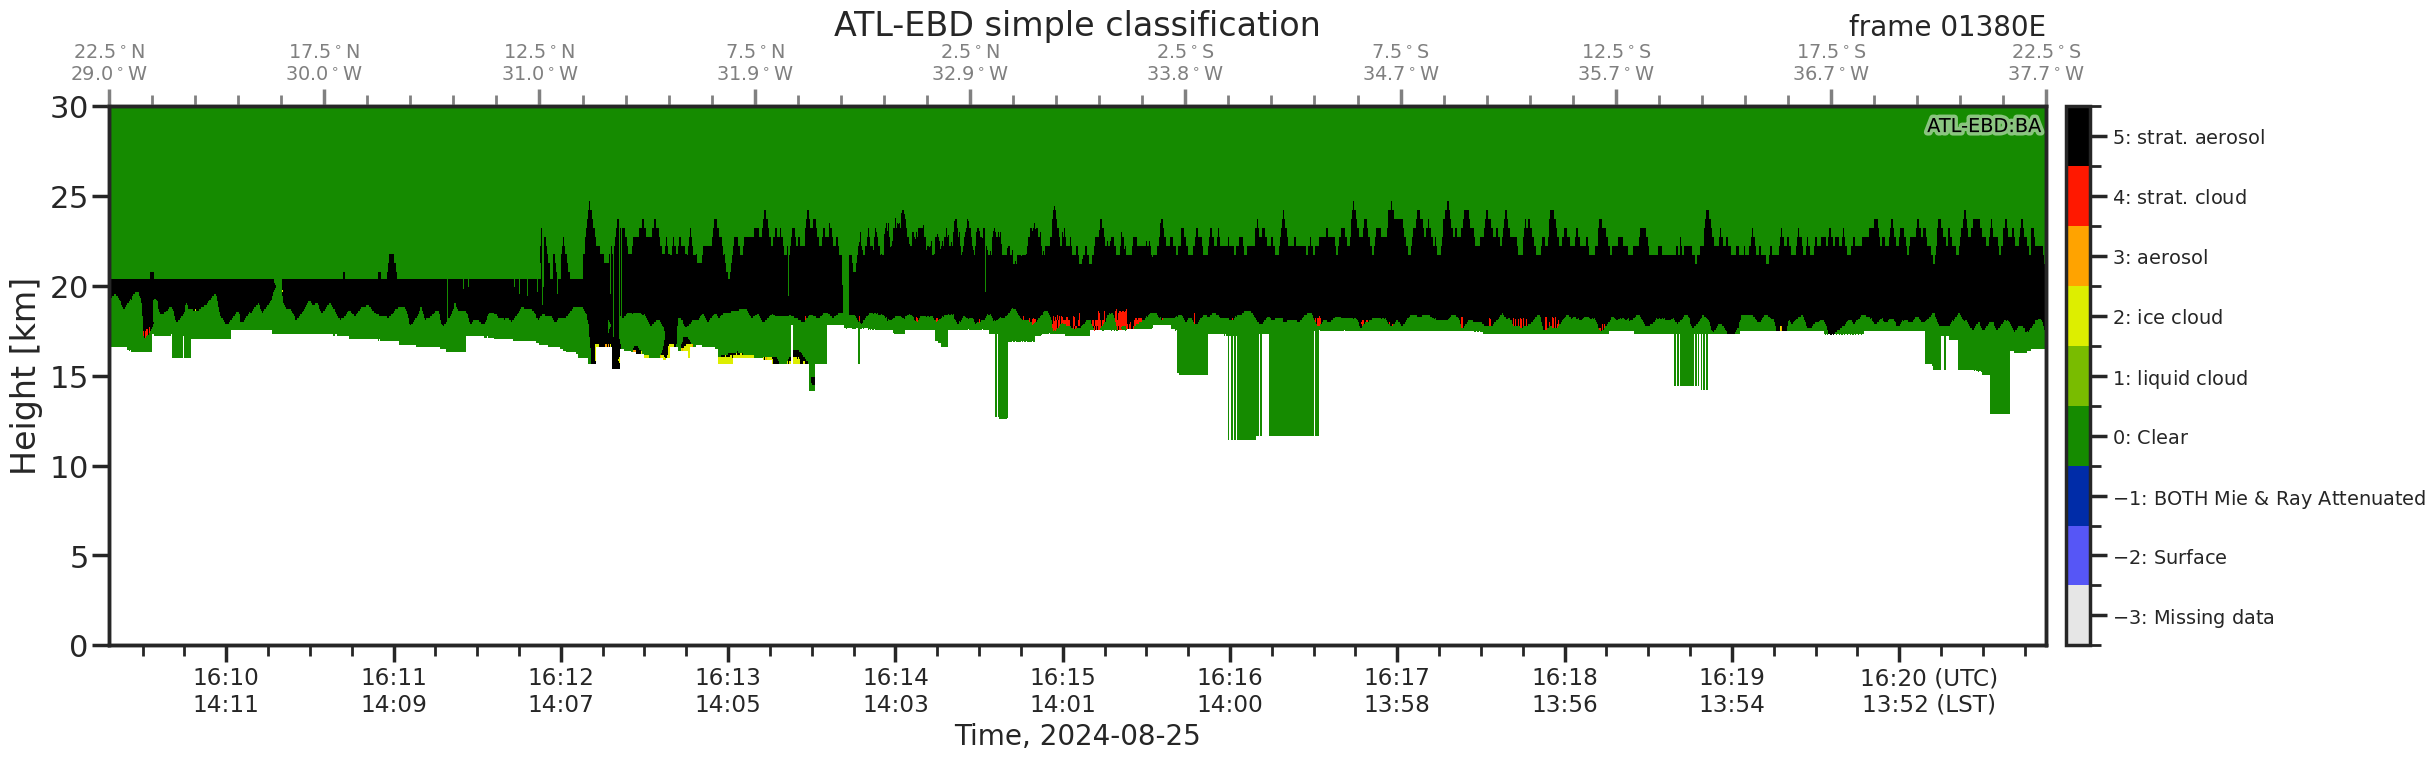

In [ ]:
fig, ax = plt.subplots(figsize=(25,7))
ecplot.plot_EC_target_classification(ax, aebd_f2, "simple_classification", colormaps.chiljet2(np.linspace(0, 1, 9)), hmin=0, hmax=30e3)

Third step - Filter out clouds 
We use a function, but also this function can be saved in a .py file and called to be used

In [ ]:
def filter_dataset_by_values(ds, filter_var, filter_values):
    """
    Filter dataset by setting specified values in a variable to NaN.
    
    Parameters
    ----------
    ds : xarray.Dataset | Input dataset to filter
    filter_var : str | Name of variable containing filter criteria
    filter_values : list | Values to filter out (set to NaN)
        
    Returns
    -------
    xarray.Dataset | Filtered dataset with specified values masked as NaN
    """
    if not isinstance(filter_values, (list, tuple, set)):
        filter_values = [filter_values]

    # Create mask for filtering
    mask = xr.concat([ds[filter_var] == val for val in filter_values], dim='filter_vals').any(dim='filter_vals')

    # Define variables to exclude from masking
    exclude_vars = {'height', 'time', 'lat', 'lon', 'latitude', 'longitude'}
    coords = set(ds.coords)

    # Only apply mask to non-coordinate, non-excluded variables
    data_vars = {}
    for var in ds.data_vars:
        if var not in exclude_vars and var not in coords:
            data_vars[var] = ds[var].where(~mask)
        else:
            data_vars[var] = ds[var]

    return xr.Dataset(data_vars=data_vars, coords=ds.coords, attrs=ds.attrs)


In [ ]:
aebd_f3 = filter_dataset_by_values(aebd_f2, 'simple_classification', [-3,-2,-1,1,2,4])
aebd_f3.encoding = aebd.encoding.copy()  # Copy encoding metadata
aebd_f3.attrs = aebd.attrs.copy()

Plot again to see the results

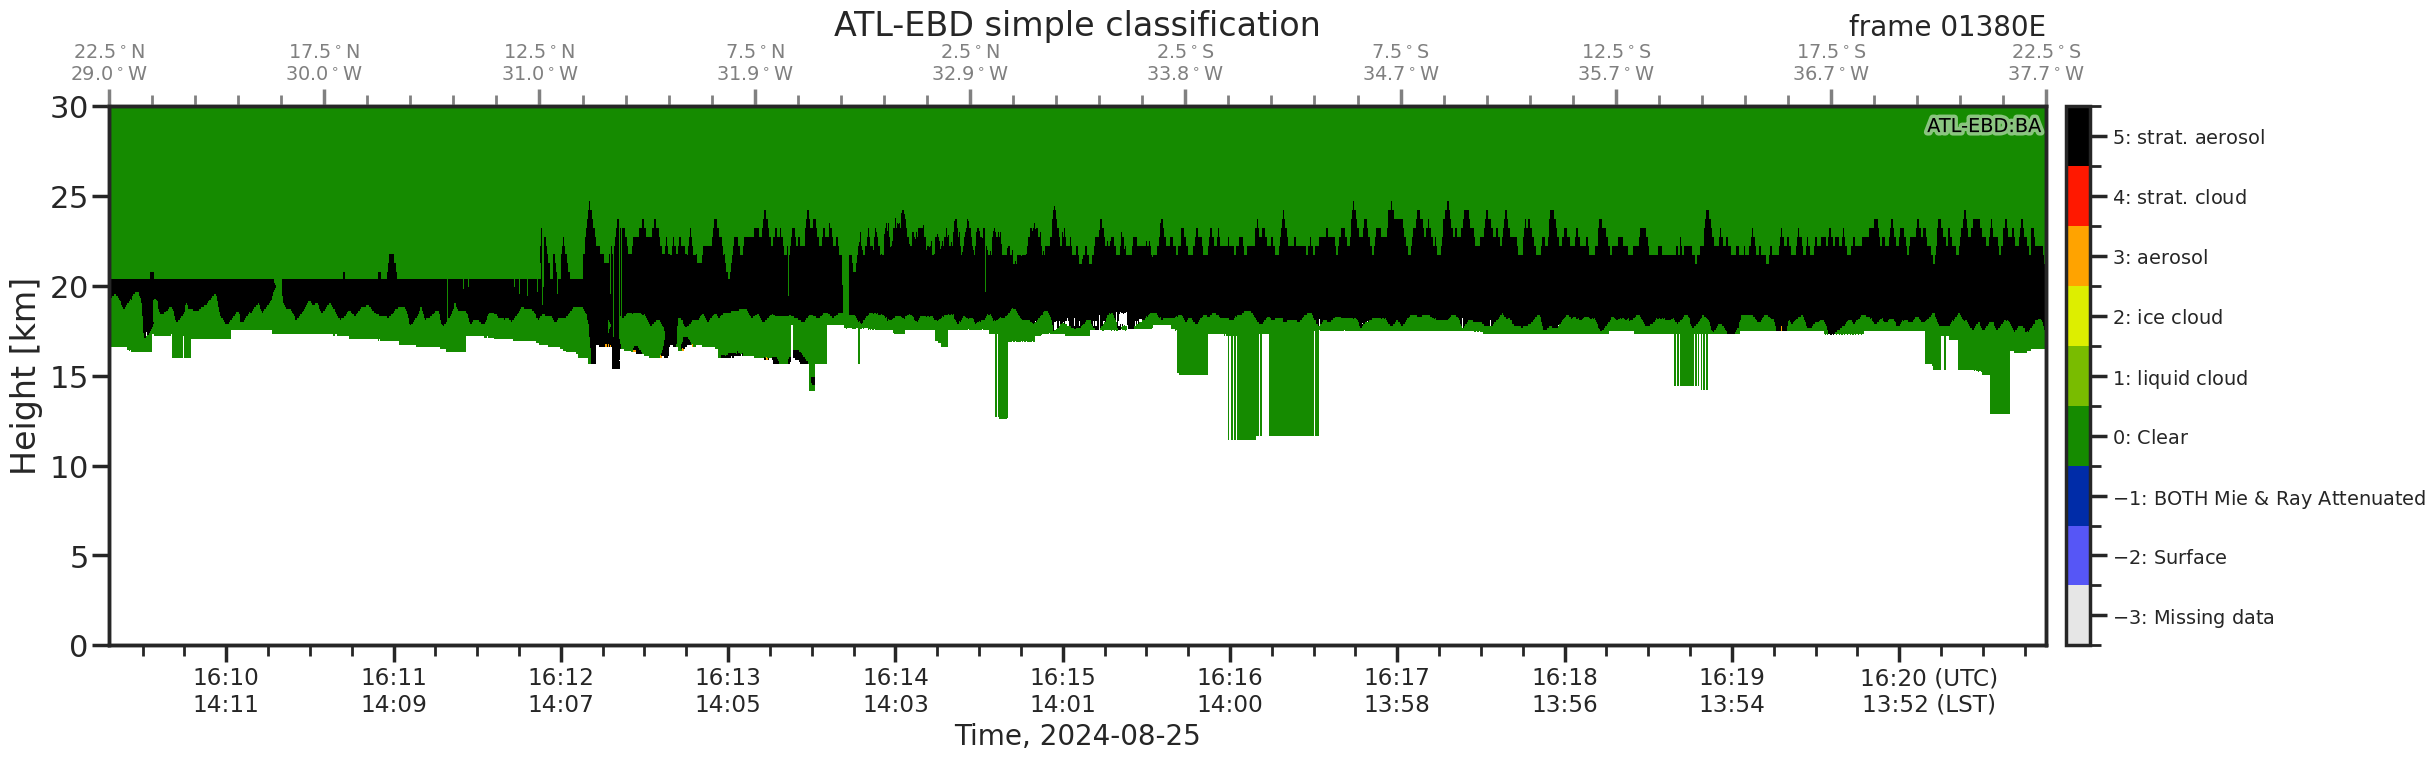

In [ ]:
fig, ax = plt.subplots(figsize=(25,7))
ecplot.plot_EC_target_classification(ax, aebd_f3, "simple_classification", colormaps.chiljet2(np.linspace(0, 1, 9)), hmin=0, hmax=30e3)

Calculate AOD function

In [ ]:
def calculate_aod(extinction, height):
    """Calculate AOD for each profile manually handling NaNs"""
    aod_values = []
    
    for i in range(extinction.shape[0]):  # Loop over each profile
        ext_profile = extinction[i, :].values     
        height_profile = height[i, :].values     
        
        # Find valid data points (not NaN)
        valid_mask = ~np.isnan(ext_profile) & ~np.isnan(height_profile)
        
        if valid_mask.sum() > 1:  # Need at least 2 points to integrate
            # Extract only the valid (non-NaN) data
            valid_ext = ext_profile[valid_mask]
            valid_height = height_profile[valid_mask]
            
            # Sort by height (ascending: low to high altitude)
            sort_idx = np.argsort(valid_height)
            
            # Integration using trapezoidal rule
            aod = np.trapz(valid_ext[sort_idx], valid_height[sort_idx])
            
            # Sanity checks (INSIDE the loop, BEFORE appending)
            if aod < 0:
                print(f"Warning: Negative AOD ({aod:.6f}) at profile {i} - setting to NaN")
                aod = np.nan
            elif aod > 1.0:  # Extreme AOD threshold
                print(f"Warning: Very high AOD ({aod:.6f}) at profile {i}")
            
            aod_values.append(aod)
        else:
            aod_values.append(np.nan)  # Not enough valid data points
    
    # Create xarray DataArray ONCE, after the loop
    aod_da = xr.DataArray(
        aod_values,
        coords={
            'along_track': extinction.coords['along_track'],           
        },
        dims=['along_track'],                                   
        name='aerosol_optical_depth',
        attrs={
            'long_name': 'Aerosol Optical Depth',
            'units': '1',                               
            'description': 'Integrated extinction coefficient above tropopause'
        }
    )

    return aod_da

In [ ]:
import numpy as np

In [ ]:
# 1. Calculate AOD
aod = calculate_aod(aebd_f3['particle_extinction_coefficient_355nm_low_resolution'], aebd_f3['height'])

# 2. Add AOD to the existing dataset aebd_f3
aebd_f3['aod'] = aod
aebd_f3['aod'].attrs['units'] = '-'

# 3. NOW select the variables you want 
variables_to_write = ['lidar_ratio_355nm_low_resolution',
                     'particle_extinction_coefficient_355nm_low_resolution', 
                     'particle_linear_depol_ratio_355nm_low_resolution',
                     'aod', 'latitude', 'time',
                     'height', 'longitude',]

# 4. Create aebd_f4 by selecting from aebd_f3
aebd_f4 = aebd_f3[variables_to_write]

# 5. Copy metadata
aebd_f4.encoding = aebd.encoding.copy()
aebd_f4.attrs = aebd.attrs.copy()

Plot the data

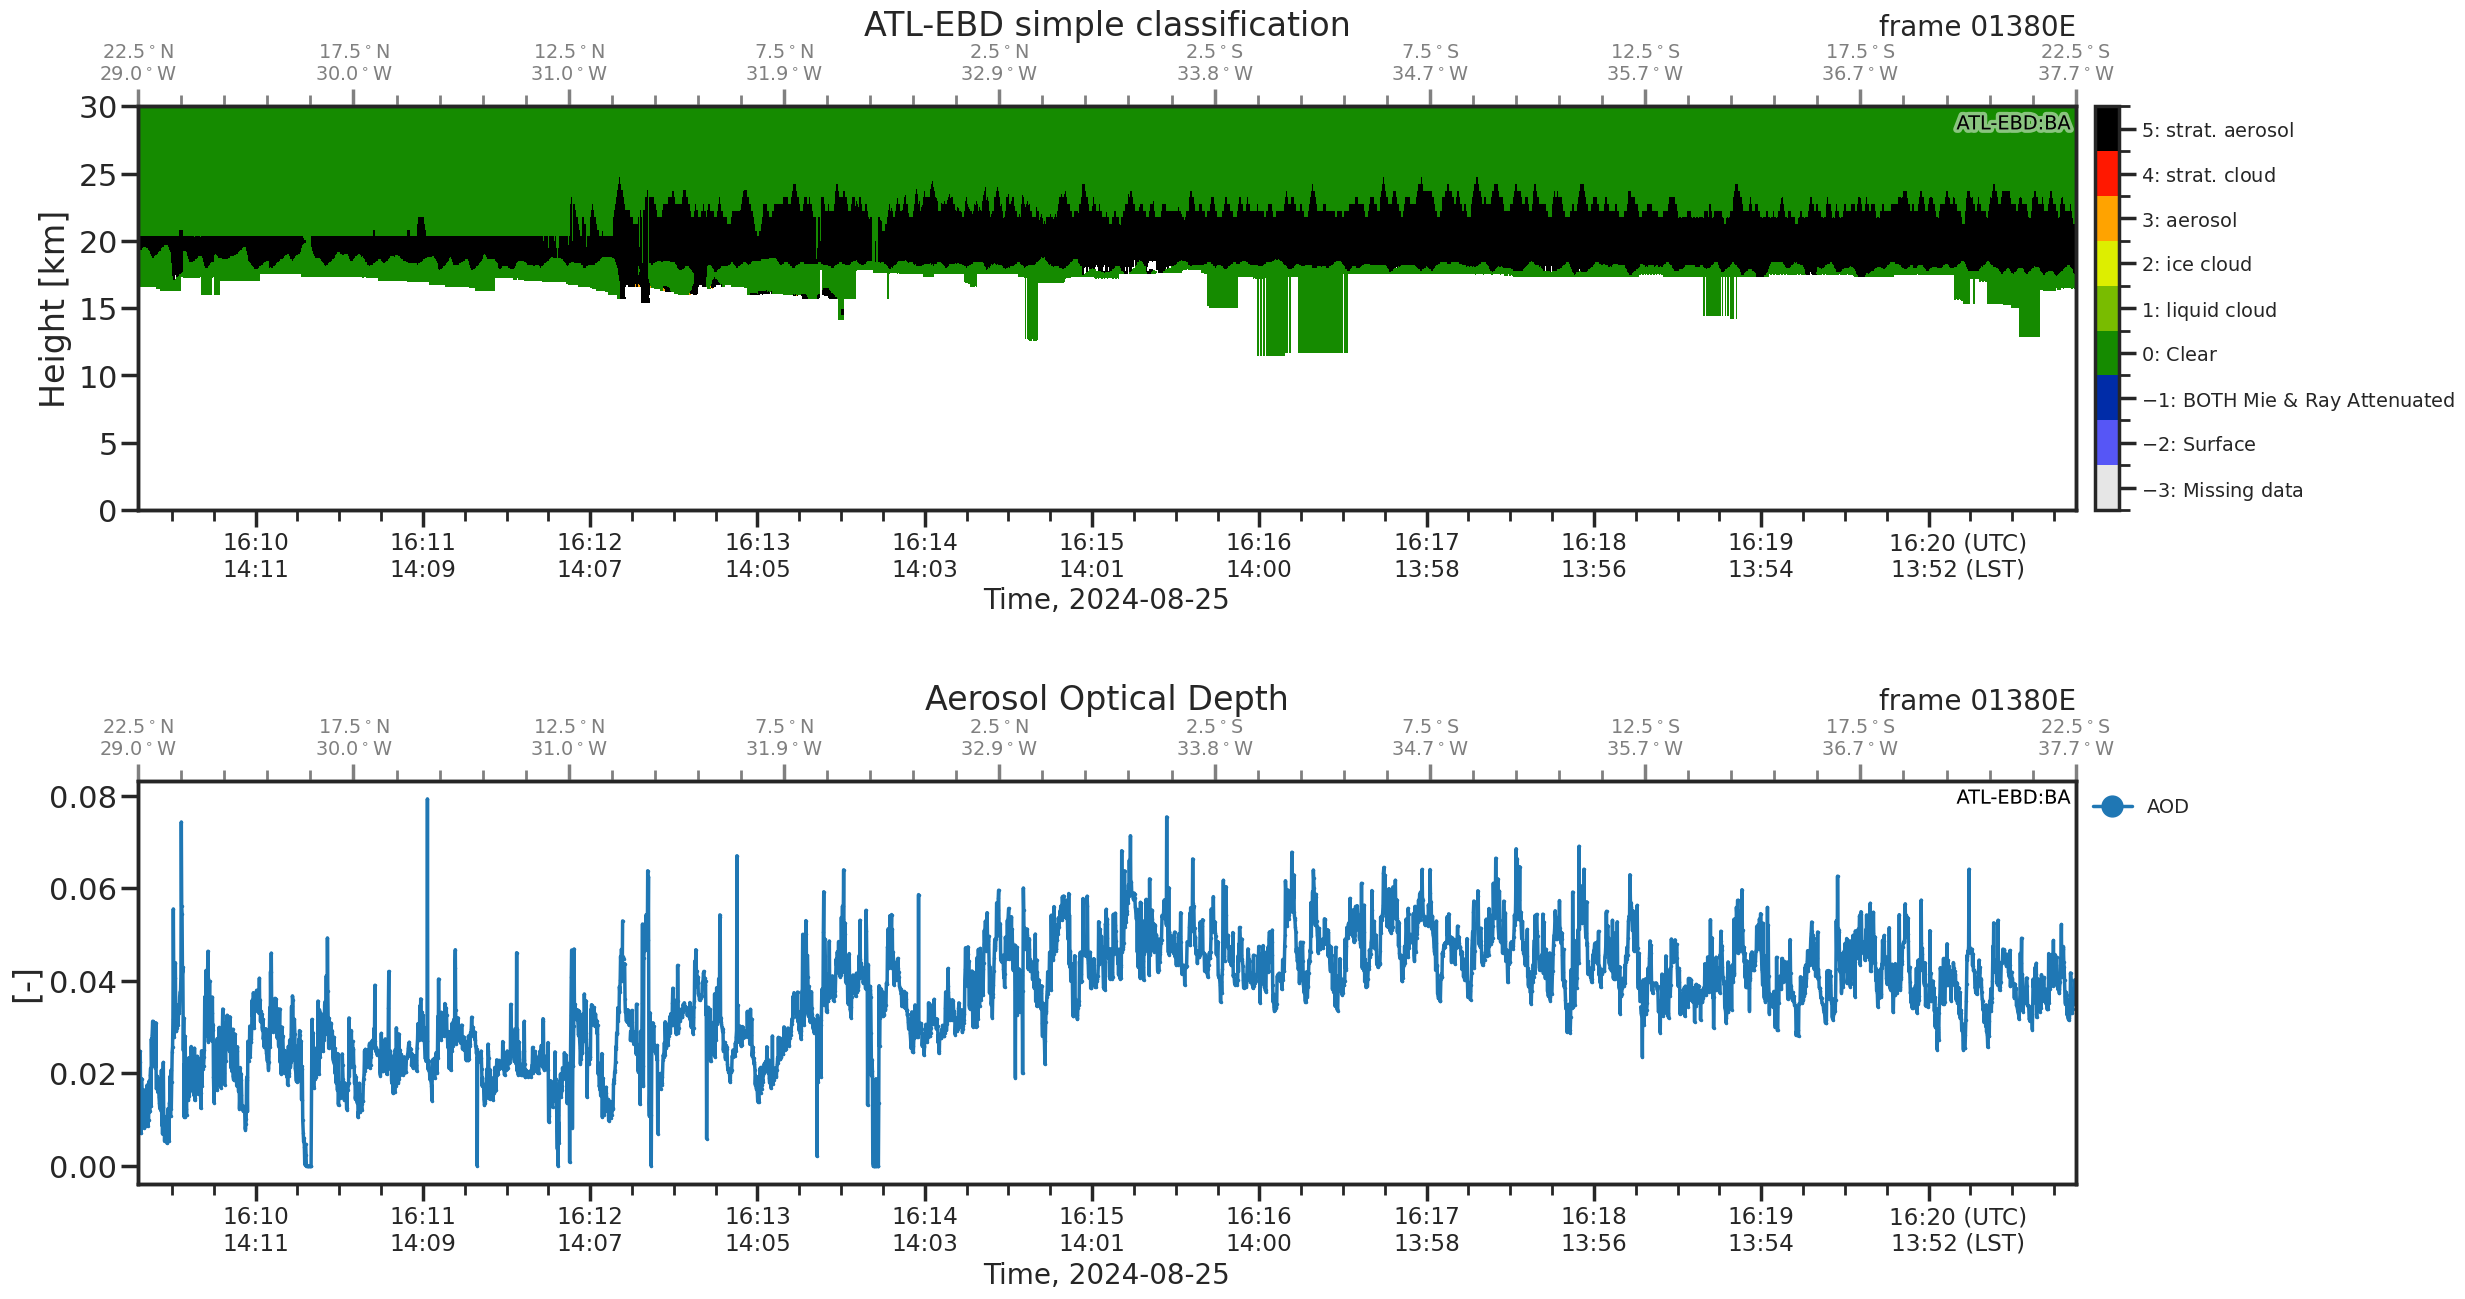

In [ ]:
nrows=2
fig, axes = plt.subplots(figsize=(25,7*nrows),nrows=nrows,gridspec_kw={'hspace':0.67})
ecplot.plot_EC_target_classification(axes[0], aebd_f3, "simple_classification", colormaps.chiljet2(np.linspace(0, 1, 9)), hmin=0, hmax=30e3)
ecplot.plot_EC_1D(axes[1], aebd_f4,{'AOD':{'xdata':aebd_f4['time'], 'ydata':aebd_f4['aod']}}, 
                     "Aerosol Optical Depth", "[-]", timevar='time', include_ruler=False)


## Download data 
You can also use your token and the url to download data and not just stream it / load it into memory. We do not recommend this approach though. 
But instead of the original data you can download the analysed data, which is much less in size compared to the original data as sen in the cell below:


In [ ]:
print('Original ATLID-AEBD product size:')
print(f"  Memory size: {aebd.nbytes / 1024**2:.2f} MB")
print(f"  Variables: {len(aebd.data_vars)}")
print(f"  Dimensions: {dict(aebd.dims)}")

print('Final analysed product size:')
print(f"  Memory size: {aebd_f4.nbytes / 1024**2:.2f} MB")
print(f"  Variables: {len(aebd_f4.data_vars)}")
print(f"  Dimensions: {dict(aebd_f4.dims)}")

print(f"Size reduction: {(1 - aebd_f4.nbytes/aebd.nbytes)*100:.1f}%")

Original ATLID-AEBD product size:
  Memory size: 237.29 MB
  Variables: 66
  Dimensions: {'along_track': 4865, 'JSG_height': 242, 'layer': 25, 'n_state': 351}
Final analysed product size:
  Memory size: 18.15 MB
  Variables: 8
  Dimensions: {'along_track': 4865, 'JSG_height': 242}
Size reduction: 92.4%


**Download the data**\
An example tutorial function to download the data to the private storage:

In [ ]:
def download_file_with_bearer_token(url, token, disable_bar=False):
  """
  Downloads a file from a given URL using a Bearer token.
  """

  try:
    headers = {"Authorization": f"Bearer {token}"}
    response = requests.get(url, headers=headers, stream=True)
    response.raise_for_status()  # Raise an exception for bad status codes
    file_size = int(response.headers.get('content-length', 0))

    chunk_size = 8 * 1024 * 1024 # Byes - 1MiB
    file_path = url.rsplit('/', 1)[-1] 
    print(file_path)
    with open(file_path, "wb") as f, tqdm(
        desc=file_path,
        total=file_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
        disable=disable_bar,
      ) as bar:
      for chunk in response.iter_content(chunk_size=chunk_size):
        read_size=f.write(chunk)
        bar.update(read_size)

    if (disable_bar): 
      print(f"File downloaded successfully to {file_path}")

  except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")

In [ ]:
download_file_with_bearer_token(ds_url, token)

ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E.h5


ECA_EXBA_ATL_EBD_2A_20240825T160913Z_20250721T105728Z_01380E.h5: 100%|██████████| 74.3M/74.3M [00:00<00:00, 121MiB/s] 


**Save the processed file**

In [ ]:
path = '/home/jovyan/my-public-bucket/earthcare_aod_01380E.nc'

aebd_f4.to_netcdf(path, format='NETCDF3_64BIT')

#aebd_f4.to_netcdf(path)
# a warning may appear but the file will be written in the directory 

For more information check out the full documentation that can be found here: [here](https://portal.maap.eo.esa.int/ini/kb/books/collaborative-environment-pal/page/earthcare-maap)